In [13]:
# import packages
using DifferentialEquations
using Plots
using OrdinaryDiffEqRosenbrock

# declare variables
Ca = 59.187
Cd = 9.57
Ea = 21179.6
Ed = 16473
eps = 0.5
rho_emp = 7164
rho_sat = 7259
R = 8.314
Aa = 10.7
Ba = 3704.6
Ad = 10.57
Bd = 3704.6
Ta = 301.15
Td = 305.15
Pas = [10., 15., 20.]
Pds = [1.5, 1.75, 2.]
Pref = 10
Peqa = Pref * exp((Aa - Ba / Ta))
Peqd = Pref * exp((Ad - Bd / Td))
uxs = [0.1, 1., 10.]
D = 1.
L = 0.8;

In [10]:
import Pkg; Pkg.add("OrdinaryDiffEqRosenbrock")

    Updating registry at `C:\Users\ameli\.julia\registries\General.toml`
   Resolving package versions...
    Updating `C:\Users\ameli\.julia\environments\v1.12\Project.toml`
⌃ [43230ef6] + OrdinaryDiffEqRosenbrock v2.2.0
    Manifest No packages added to or removed from `C:\Users\ameli\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
   1807.4 ms  ✓ Xorg_libICE_jll
   1704.4 ms  ✓ Xorg_libXau_jll
   1698.3 ms  ✓ libdrm_jll
   1725.9 ms  ✓ mtdev_jll
   1712.5 ms  ✓ EpollShim_jll
   1749.4 ms  ✓ LLVMOpenMP_jll
   1685.7 ms  ✓ Xorg_libXdmcp_jll
   1280.1 ms  ✓ SCOTCH_jll
   1314.1 ms  ✓ libevdev_jll
   1323.6 ms  ✓ eudev_jll
   1363.7 ms  ✓ Dbus_jll
   1344.8 ms  ✓ Xorg_xtrans_jll
   1664.6 ms  ✓ Conda
   2102.5 ms  ✓ MPICH_jll
    949.5 ms  ✓ Wayland_jll
    934.8 ms  ✓ Xorg_libX11_jll
   1061.8 ms  ✓ Xorg_xcb_util_jll
   1294.9 ms  ✓ Xorg_libXfixes_jll
   1283.3 ms  ✓ Xorg_libXft_jll
   1271.8 ms  ✓ Xorg_libXinerama_jll
   1291.7 ms  ✓ Xorg_libxkbfile_jll
   1267.1 ms 

## 0D Transient Reactor Models

### Only Solid Density in Spatially Homogenous Reactor

<b>Absorption<b>

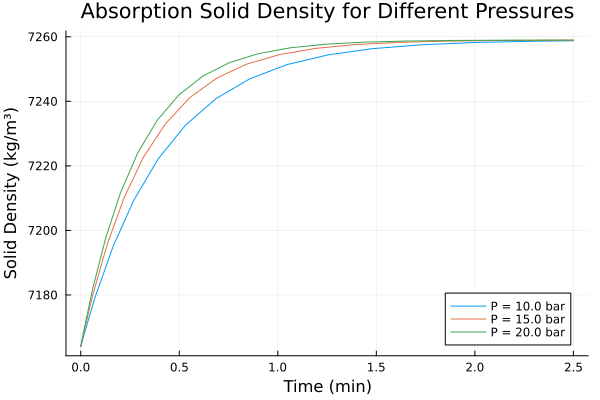

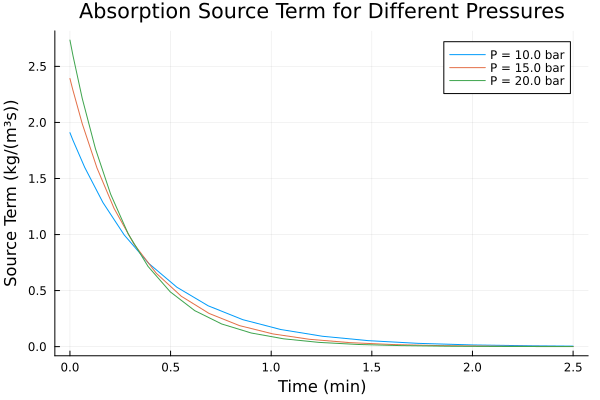

In [14]:
plt1 = plot(title="Absorption Solid Density for Different Pressures", xlabel="Time (min)", ylabel="Solid Density (kg/m³)")
plt2 = plot(title="Absorption Source Term for Different Pressures", xlabel="Time (min)", ylabel="Source Term (kg/(m³s))")

for P in Pas
    # problem set-up: rhs function that defines the ODE
    function rhs(rho_s,p,t)
        return (Ca * exp(-Ea / (R * Ta)) * log(P / Peqa) * (rho_sat - rho_s)) / (1 - eps)
    end 

    # problem set-up: initial condition
    rho_s_init = rho_emp

    # problem set-up: set time span
    Tend = 150
    tspan = (0.0,Tend)

    # problem set-up: define ODE problem 
    prob = ODEProblem(rhs,rho_s_init,tspan)

    # solve: perform time integration 
    sol = solve(prob,AutoVern7(Rodas5()),reltol=1e-8,abstol=1e-8)

    # post-process: plot computed solution 
    plot!(plt1, sol.t/60, sol.u, label="P = $P bar")

    # post-process:evaluate and plot the source term 
    mdot = (1 - eps) * rhs.(sol.u,1,sol.t)
    plot!(plt2, sol.t/60, mdot, label="P = $P bar")
end

display(plt1)
display(plt2)

<b>Desorption<b>

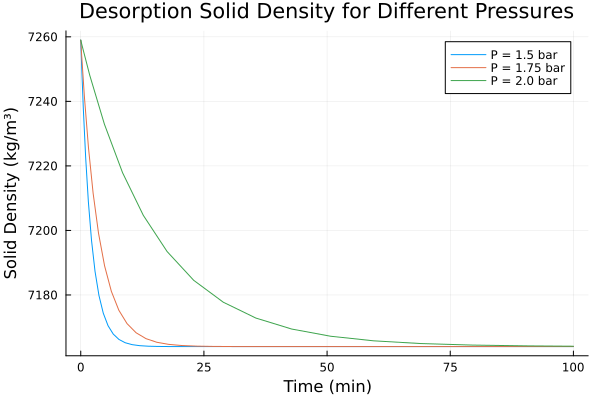

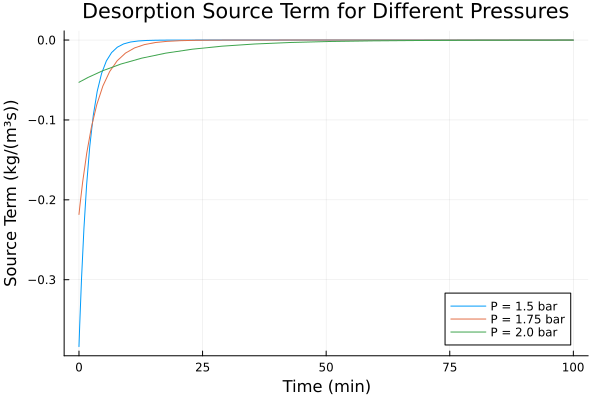

In [15]:
plt1 = plot(title="Desorption Solid Density for Different Pressures", xlabel="Time (min)", ylabel="Solid Density (kg/m³)")
plt2 = plot(title="Desorption Source Term for Different Pressures", xlabel="Time (min)", ylabel="Source Term (kg/(m³s))")

for P in Pds
    # problem set-up: rhs function that defines the ODE
    function rhs(rho_s,p,t)
        return Cd * exp(-Ed / (R * Td)) * (P - Peqd) / Peqd * (rho_s - rho_emp) / (1 - eps)
    end 

    # problem set-up: initial condition
    rho_s_init = rho_sat

    # problem set-up: set time span
    Tend = 6000
    tspan = (0.0,Tend)

    # problem set-up: define ODE problem 
    prob = ODEProblem(rhs,rho_s_init,tspan)

    # solve: perform time integration 
    sol = solve(prob,AutoVern7(Rodas5()),reltol=1e-8,abstol=1e-8)

    # post-process: plot computed solution 
    plot!(plt1, sol.t/60, sol.u, label="P = $P bar")

    # post-process:evaluate and plot the source term 
    mdot = (1 - eps) * rhs.(sol.u,1,sol.t)
    plot!(plt2, sol.t/60, mdot, label="P = $P bar")
end

display(plt1)
display(plt2)

### Coupled Solid/Gas Density in Spatially Homogenous Reactor

<b>Absorption<b>

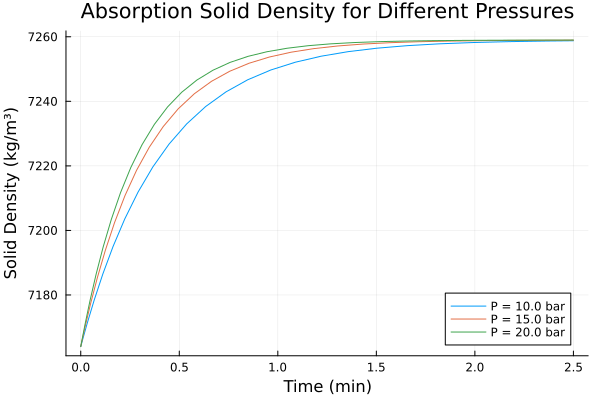

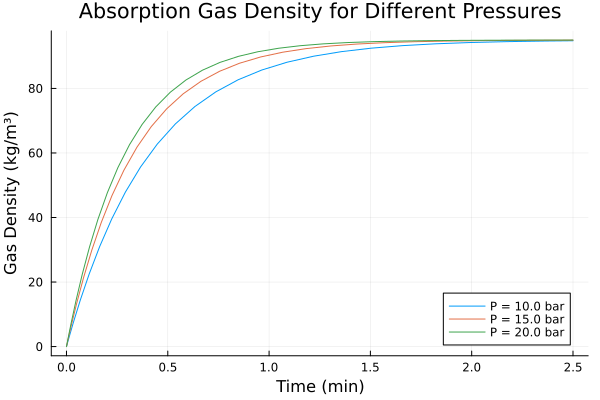

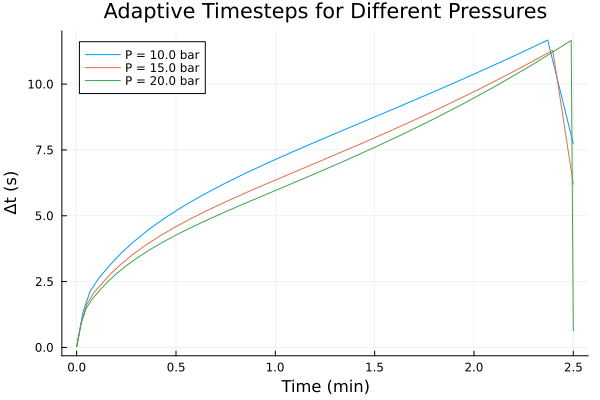

In [17]:
plt1 = plot(title="Absorption Solid Density for Different Pressures", xlabel="Time (min)", ylabel="Solid Density (kg/m³)")
plt2 = plot(title="Absorption Gas Density for Different Pressures", xlabel="Time (min)", ylabel="Gas Density (kg/m³)")
plt3 = plot(title="Adaptive Timesteps for Different Pressures", xlabel="Time (min)", ylabel="Δt (s)")

for P in Pas
    # problem set-up: rhs function that defines the ODE
    function rhs(drho_s,rho_s,p,t)
        mdot = Ca * exp(-Ea / (R * Ta)) * log(P / Peqa) * (rho_sat - rho_s[1])
        drho_s[1] = mdot / (1 - eps)
        drho_s[2] = mdot / eps
    end

    # problem set-up: initial condition
    rho_s_init = [rho_emp, 0]

    # problem set-up: set time span
    Tend = 150
    tspan = (0.0,Tend)

    # problem set-up: define ODE problem 
    prob = ODEProblem(rhs,rho_s_init,tspan)

    # solve: perform time integration 
    sol = solve(prob,AutoVern7(Rodas5()),reltol=1e-8,abstol=1e-8)
    dt = diff(sol.t)

    # post-process: plot computed solution 
    plot!(plt1, sol.t/60, [v[1] for v in sol.u], label="P = $P bar")
    plot!(plt2, sol.t/60, [v[2] for v in sol.u], label="P = $P bar")
    plot!(plt3, sol.t[2:end] ./ 60, dt,label="P = $P bar")
end

display(plt1)
display(plt2)
display(plt3)

<b>Desorption<b>

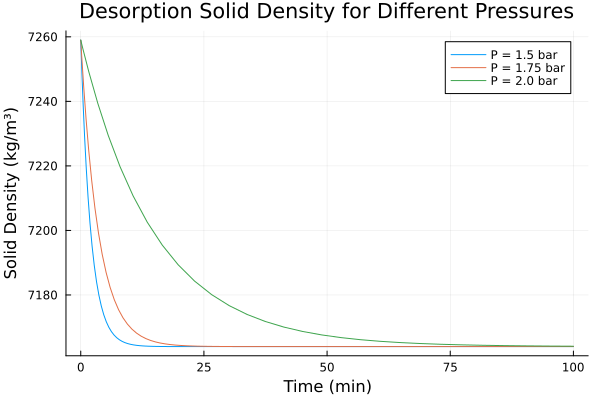

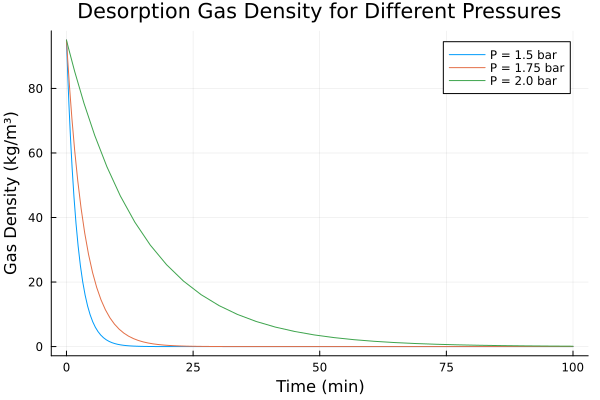

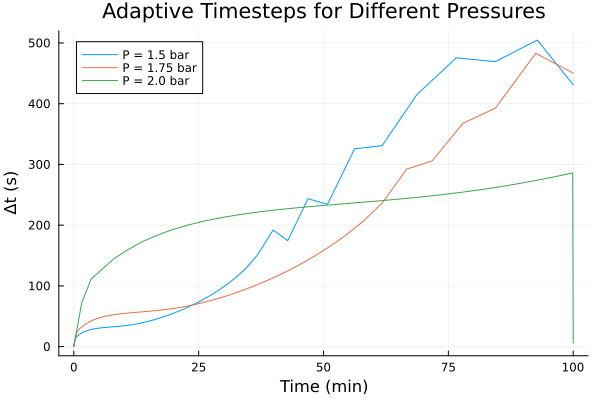

In [18]:
plt1 = plot(title="Desorption Solid Density for Different Pressures", xlabel="Time (min)", ylabel="Solid Density (kg/m³)")
plt2 = plot(title="Desorption Gas Density for Different Pressures", xlabel="Time (min)", ylabel="Gas Density (kg/m³)")
plt3 = plot(title="Adaptive Timesteps for Different Pressures", xlabel="Time (min)", ylabel="Δt (s)")

for P in Pds
    # problem set-up: rhs function that defines the ODE
    function rhs(drho_s,rho_s,p,t)
        mdot = Cd * exp(-Ed / (R * Td)) * (P - Peqd) / Peqd * (rho_s[1] - rho_emp)
        drho_s[1] = mdot / (1 - eps)
        drho_s[2] = mdot / eps
    end

    # problem set-up: initial condition
    rho_s_init = [rho_sat, rho_sat - rho_emp]

    # problem set-up: set time span
    Tend = 6000
    tspan = (0.0,Tend)

    # problem set-up: define ODE problem 
    prob = ODEProblem(rhs,rho_s_init,tspan)

    # solve: perform time integration 
    sol = solve(prob,AutoVern7(Rodas5()),reltol=1e-8,abstol=1e-8)
    dt = diff(sol.t)
    
    # post-process: plot computed solution 
    plot!(plt1, sol.t/60, [v[1] for v in sol.u], label="P = $P bar")
    plot!(plt2, sol.t/60, [v[2] for v in sol.u], label="P = $P bar")
    plot!(plt3, sol.t[2:end] ./ 60, dt,label="P = $P bar")
end

display(plt1)
display(plt2)
display(plt3)